# Customer Churn Predictor
## Context
Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs.

## Content
Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

The data set includes information about:

- Customers who left within the last month – the column is called Churn
- Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
- Demographic info about customers – gender, age range, and if they have partners and dependents

## Importing dependencies


pip install xgboost lightgbm

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

## Exploration & Data loading

In [42]:
df = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')
df.shape

(7043, 21)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [44]:
df.head(20)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [45]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [46]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [47]:
pd.set_option('display.max_columns', None)  # Show all columns in the DataFrame
pd.set_option('display.max_rows', None)     # Show all rows in the DataFrame

## Binary Encoding

In [48]:
# Binary categorical columns (2 unique values)
binary_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn'
]

# Map Yes/No and Male/Female to 0/1
df[binary_cols] = df[binary_cols].replace({
    'Yes': 1, 'No': 0,
    'Male': 1, 'Female': 0
})

C:\Users\Balaji\AppData\Local\Temp\ipykernel_13896\2830485926.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({


In [49]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


## One-Hot encoding

In [50]:
# Categorical columns with > 2 unique values
multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

# One-hot encode
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

In [51]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.5,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


## Data Cleaning

In [52]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
df = df.dropna(subset=['TotalCharges']) #logistic regression cause it doesnot accept NaN values

In [53]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [54]:
df = df.drop('customerID', axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   bool   
 11  MultipleL

In [55]:
bool_columns = df.select_dtypes(include='bool').columns
df[bool_columns]=df[bool_columns].astype(int)
df.isnull().sum()

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV

## Data Visualization

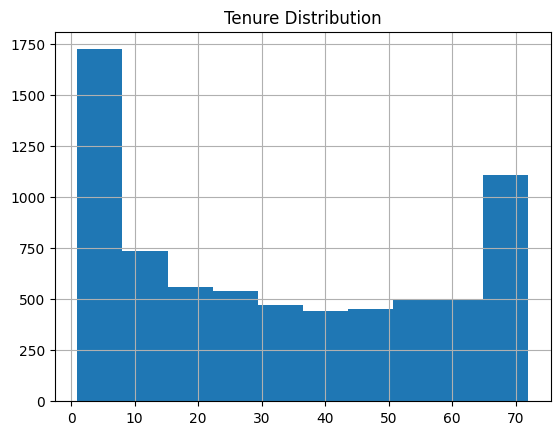

In [56]:
df["tenure"].hist()
plt.title("Tenure Distribution")
plt.show()

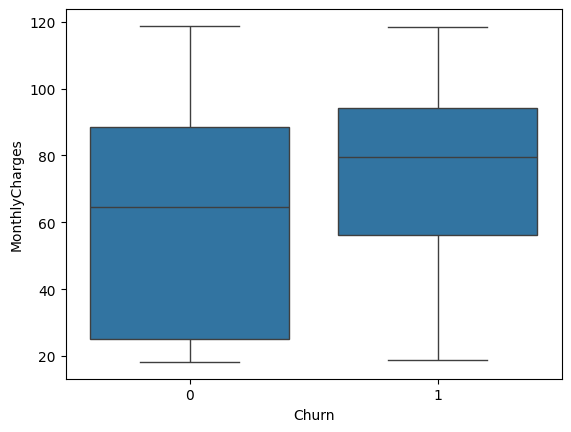

In [57]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

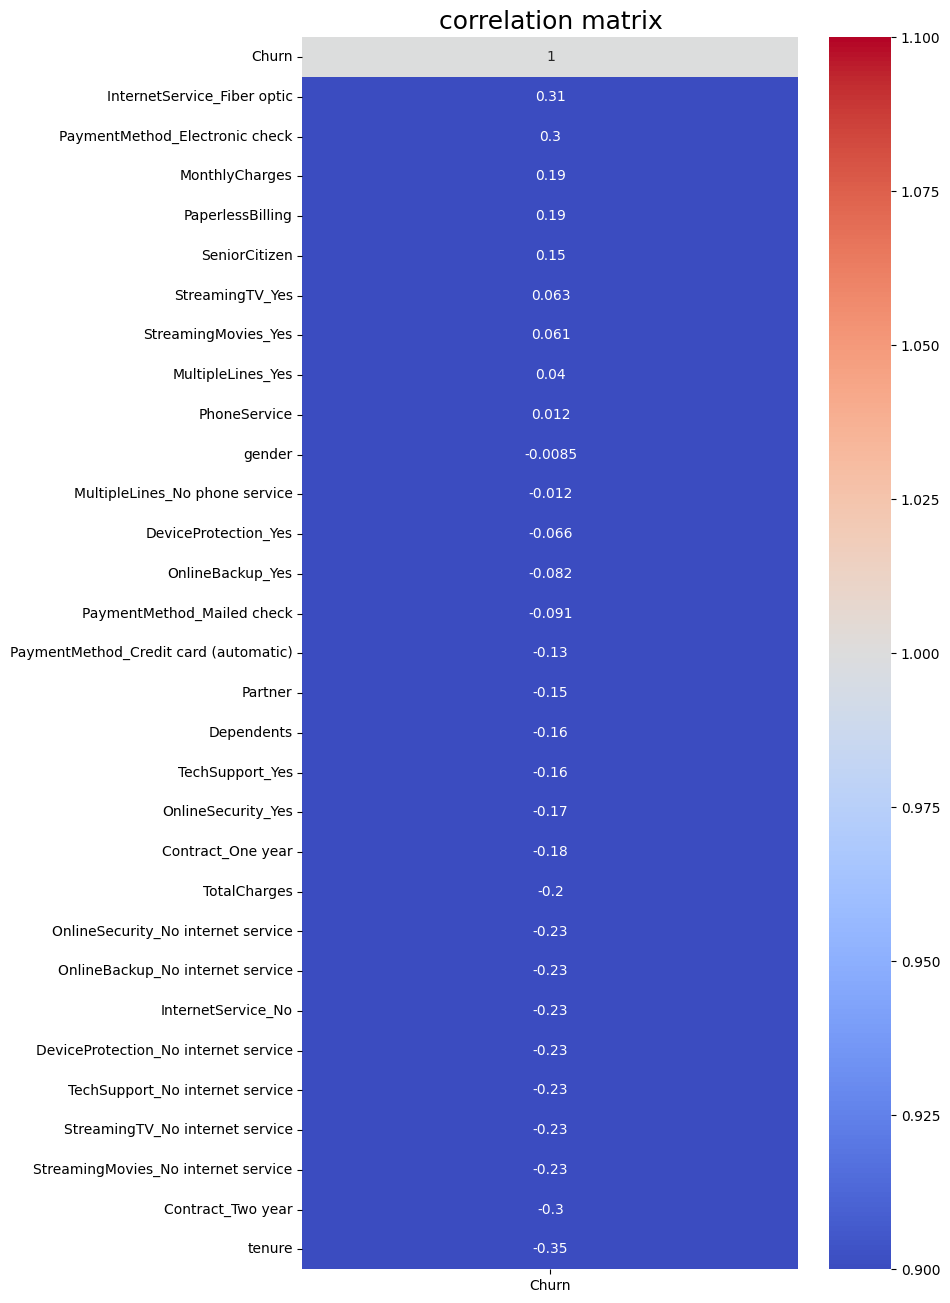

In [58]:
coor_matrix = df.corr(numeric_only = True)
churn_corr = coor_matrix[['Churn']].sort_values(by= 'Churn', ascending=False)
plt.figure(figsize = (8,16))
sns.heatmap(churn_corr, annot = True, cmap='coolwarm', vmin=1, vmax=1)
plt.title('correlation matrix', fontsize = 18)
plt.show()

In [59]:
# We need to collapse redundant columns before running VIF
df['No_internet_service'] = (
    df['OnlineSecurity_No internet service'] |
    df['OnlineBackup_No internet service'] |
    df['DeviceProtection_No internet service'] |
    df['TechSupport_No internet service'] |
    df['StreamingTV_No internet service'] |
    df['StreamingMovies_No internet service']
).astype(int)

# df['No_internet_service']

In [60]:
# Drop the original redundant dummies
drop_cols = [col for col in df.columns if 'No internet service' in col]
# drop_cols
df = df.drop(columns=drop_cols)

In [61]:
# Handle PhoneService redundancy
if 'MultipleLines_No phone service' in df.columns:
    df['No_phone_service'] = df['MultipleLines_No phone service'].astype(int)
    df = df.drop(columns=['MultipleLines_No phone service'])

In [62]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

## Machine learning

In [63]:
x = df.drop("Churn", axis=1)
y = df["Churn"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [64]:
def evaluate_model(model, x_train, x_test, y_train, y_test):

    start_train = time.time()
    model.fit(x_train, y_train)
    train_time = time.time() - start_train
    print(f"Training time: {train_time:.2f} seconds")

    start_pred = time.time()
    preds = model.predict(x_test)
    probs = model.predict_proba(x_test)[:,1]
    pred_time = time.time() - start_pred
    print(f"Prediction time: {pred_time:.4f} seconds")
    
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("Recall:", recall_score(y_test, preds))
    print("F1:", f1_score(y_test, preds))
    print("ROC AUC:", roc_auc_score(y_test, probs))
    
    print("\nClassification Report:\n")
    print(classification_report(y_test, preds))
    
    cm = confusion_matrix(y_test, preds)
    
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title("Confusion Matrix")
    plt.show()

In [65]:
def threshold_tuning(model, x_test, y_test):
    proba = model.predict_proba(x_test)[:, 1]
    
    print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
    for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
        preds = (proba >= thresh).astype(int)
        prec = precision_score(y_test, preds, pos_label=1)
        rec = recall_score(y_test, preds, pos_label=1)
        f1 = f1_score(y_test, preds, pos_label=1)
        print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

### Logistic Regression

C:\Users\Balaji\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training time: 1.03 seconds
Prediction time: 0.0018 seconds
Accuracy: 0.7889125799573561
Precision: 0.6245954692556634
Recall: 0.516042780748663
F1: 0.5651537335285505
ROC AUC: 0.8320218873433382

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.62      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



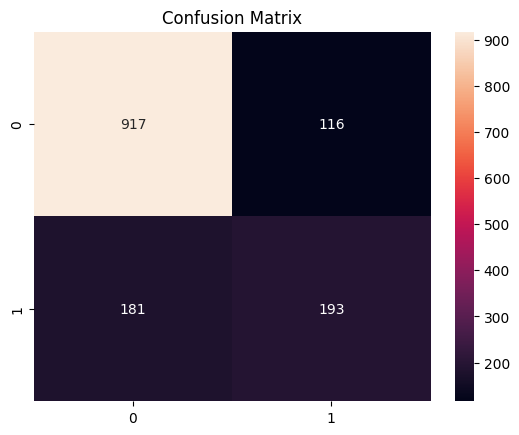

In [84]:
log_model = LogisticRegression(max_iter=1000)

evaluate_model(
    log_model,
    x_train,
    x_test,
    y_train,
    y_test
)

In [67]:
print("Threshold tuning for LOGISTIC REGRESSION")
threshold_tuning(log_model, x_test, y_test)


Threshold tuning for LOGISTIC REGRESSION
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.498   0.818   0.619   
0.3     0.527   0.762   0.623   
0.35    0.540   0.706   0.612   
0.4     0.579   0.650   0.612   
0.45    0.595   0.580   0.587   
0.5     0.625   0.516   0.565   


### RandomForest Classifier

Training time: 1.07 seconds
Prediction time: 0.1884 seconds
Accuracy: 0.7882018479033405
Precision: 0.6417910447761194
Recall: 0.45989304812834225
F1: 0.5358255451713395
ROC AUC: 0.8170066935513095

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.64      0.46      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.78      1407



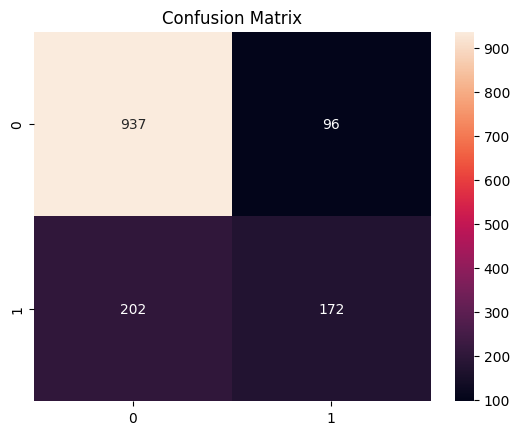

In [86]:
rf_model = RandomForestClassifier(n_estimators=300,
    class_weight='balanced',   # handles imbalance for you
    random_state=42,
    n_jobs=-1)

evaluate_model(
    rf_model,
    x_train,
    x_test,
    y_train,
    y_test
)

In [69]:
print("Threshold tuning for RANDOM FOREST")
threshold_tuning(rf_model, x_test, y_test)


Threshold tuning for RANDOM FOREST
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.479   0.775   0.592   
0.3     0.514   0.714   0.598   
0.35    0.533   0.650   0.586   
0.4     0.574   0.602   0.587   
0.45    0.601   0.524   0.560   
0.5     0.643   0.468   0.542   


### XGBoost Classifier

Training time: 0.79 seconds
Prediction time: 0.0252 seconds
Accuracy: 0.7427149964463398
Precision: 0.512396694214876
Recall: 0.6631016042780749
F1: 0.578088578088578
ROC AUC: 0.8167116182035605

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.77      0.81      1033
           1       0.51      0.66      0.58       374

    accuracy                           0.74      1407
   macro avg       0.69      0.72      0.70      1407
weighted avg       0.77      0.74      0.75      1407



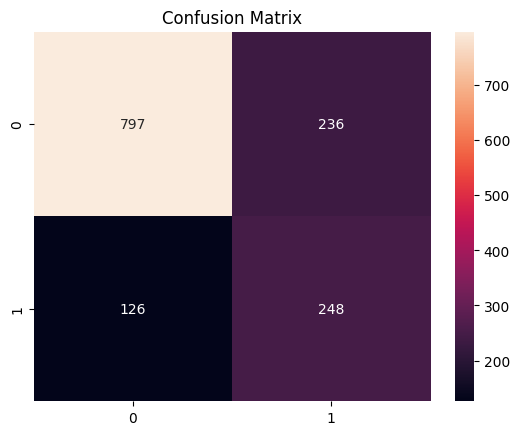

In [87]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss')

evaluate_model(
    xgb_model,
    x_train,
    x_test,
    y_train,
    y_test
)

In [71]:
print("Threshold tuning for XGBOOST")
threshold_tuning(xgb_model, x_test, y_test)


Threshold tuning for XGBOOST
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.452   0.834   0.586   
0.3     0.462   0.805   0.587   
0.35    0.472   0.781   0.589   
0.4     0.482   0.746   0.586   
0.45    0.493   0.690   0.575   
0.5     0.512   0.663   0.578   


### LightGBM Classifier

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002564 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training time: 0.88 seconds
Prediction time: 0.0180 seconds
Accuracy: 0.7427149964463398
Precision: 0.5122448979591837
Recall: 0.6711229946524064
F1: 0.5810185185185185
ROC AUC: 0.8156012030791371

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.77      0.81      1033
           1       0.51      0.67    

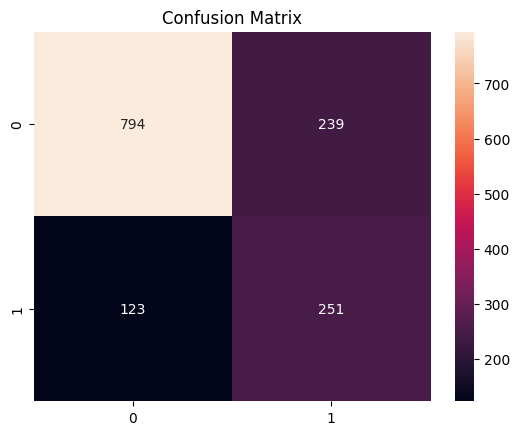

In [75]:
lgbm_model = LGBMClassifier(n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)

evaluate_model(
    lgbm_model,
    x_train,
    x_test,
    y_train,
    y_test
)

In [76]:
print("Threshold tuning for LightGBM")
threshold_tuning(lgbm_model, x_test, y_test)

Threshold tuning for LightGBM
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.460   0.845   0.596   
0.3     0.466   0.816   0.593   
0.35    0.478   0.778   0.592   
0.4     0.477   0.730   0.577   
0.45    0.494   0.703   0.581   
0.5     0.512   0.671   0.581   


## Model Comparison

In [79]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'),
    "LightGBM": LGBMClassifier(n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)
}

results = []

for name, model in models.items():
    
    model.fit(x_train, y_train)
    
    preds = model.predict(x_test)
    probs = model.predict_proba(x_test)[:,1]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC AUC": roc_auc_score(y_test, probs)
    })

results_df = pd.DataFrame(results)
results_df

C:\Users\Balaji\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000678 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression,0.788913,0.624595,0.516043,0.565154,0.832022
1,Random Forest,0.788202,0.641791,0.459893,0.535826,0.817007
2,XGBoost,0.742715,0.512397,0.663102,0.578089,0.816712
3,LightGBM,0.742715,0.512245,0.671123,0.581019,0.815601


### Best Model Selection

In [80]:
results_df.sort_values("ROC AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression,0.788913,0.624595,0.516043,0.565154,0.832022
1,Random Forest,0.788202,0.641791,0.459893,0.535826,0.817007
2,XGBoost,0.742715,0.512397,0.663102,0.578089,0.816712
3,LightGBM,0.742715,0.512245,0.671123,0.581019,0.815601


## Conclusion


- Logistic Regression provides baseline performance
- Random Forest best accuracy but low recall
- XGBoost gives good recall and best ROC-AUC
- LightGBM fastest training and best recall

Selected model for API: XGBoost

Justification:
Multiple models including Logistic Regression, Random Forest, and XGBoost were evaluated. XGBoost was selected as the final model because it achieved the highest ROC-AUC and recall, and effectively captured nonlinear relationships in customer behavior data.